In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')

In [ ]:
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [ ]:
print(df.shape)
print(df.dtypes)

(32581, 12)
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [ ]:
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [ ]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(165)

In [ ]:
print(df.dtypes)



person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


In [ ]:
# 7. EDA / Data Understanding

# Unique values in categorical columns
print(df['person_home_ownership'].unique())
print(df['loan_intent'].unique())
print(df['loan_grade'].unique())
print(df['cb_person_default_on_file'].unique())

# Target distribution
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))

['RENT' 'OWN' 'MORTGAGE' 'OTHER']
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
['D' 'B' 'C' 'A' 'E' 'F' 'G']
['Y' 'N']
loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


/tmp/ipykernel_2645/4150310486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette=['#4CAF50', '#E74C3C'])


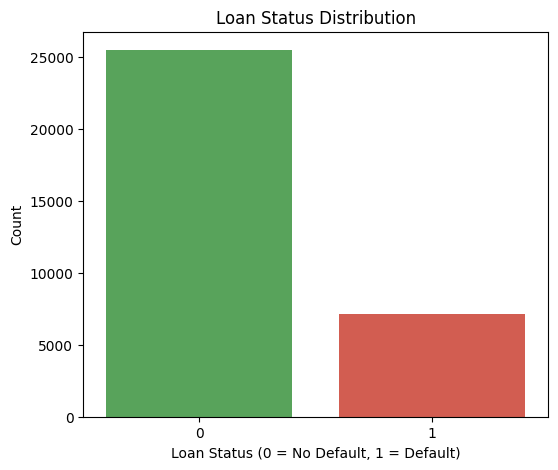

In [ ]:
# Target Distribution
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='loan_status', palette=['#4CAF50', '#E74C3C'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

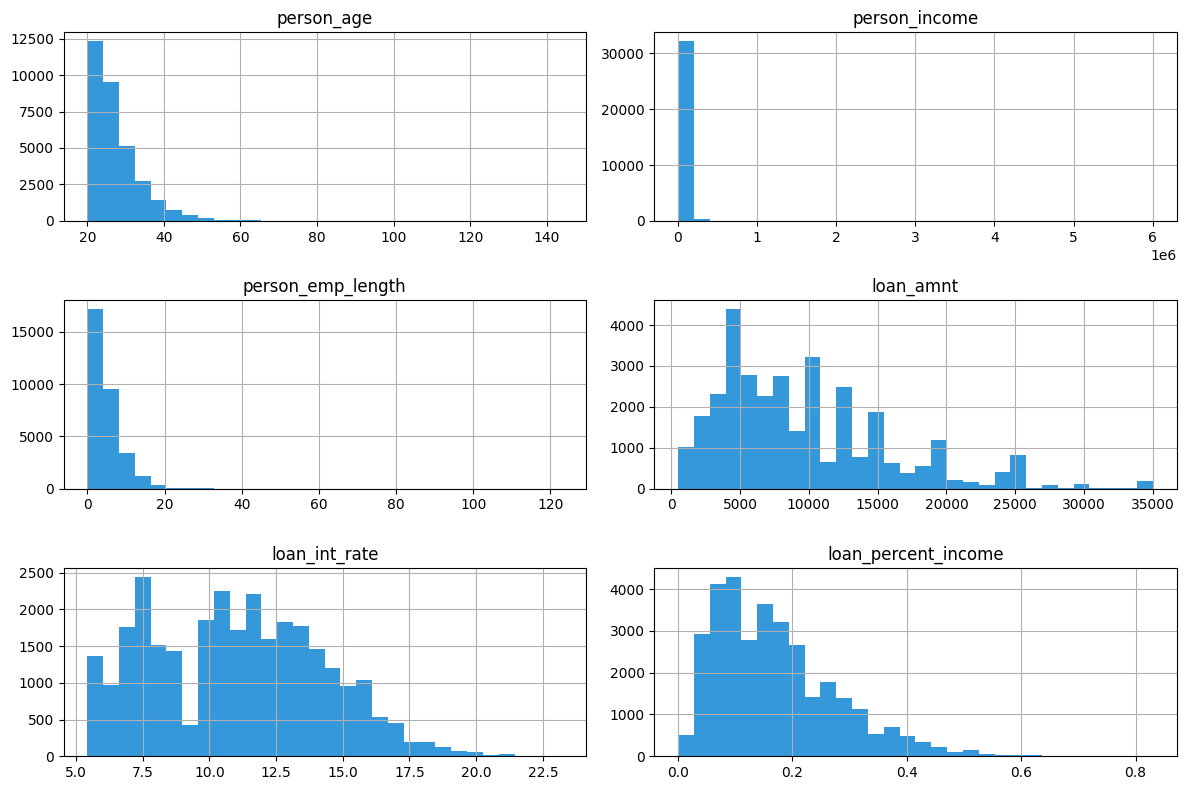

In [ ]:
# Numerical Distributions
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

df[num_cols].hist(figsize=(12,8), bins=30, color='#3498DB')
plt.tight_layout()
plt.show()

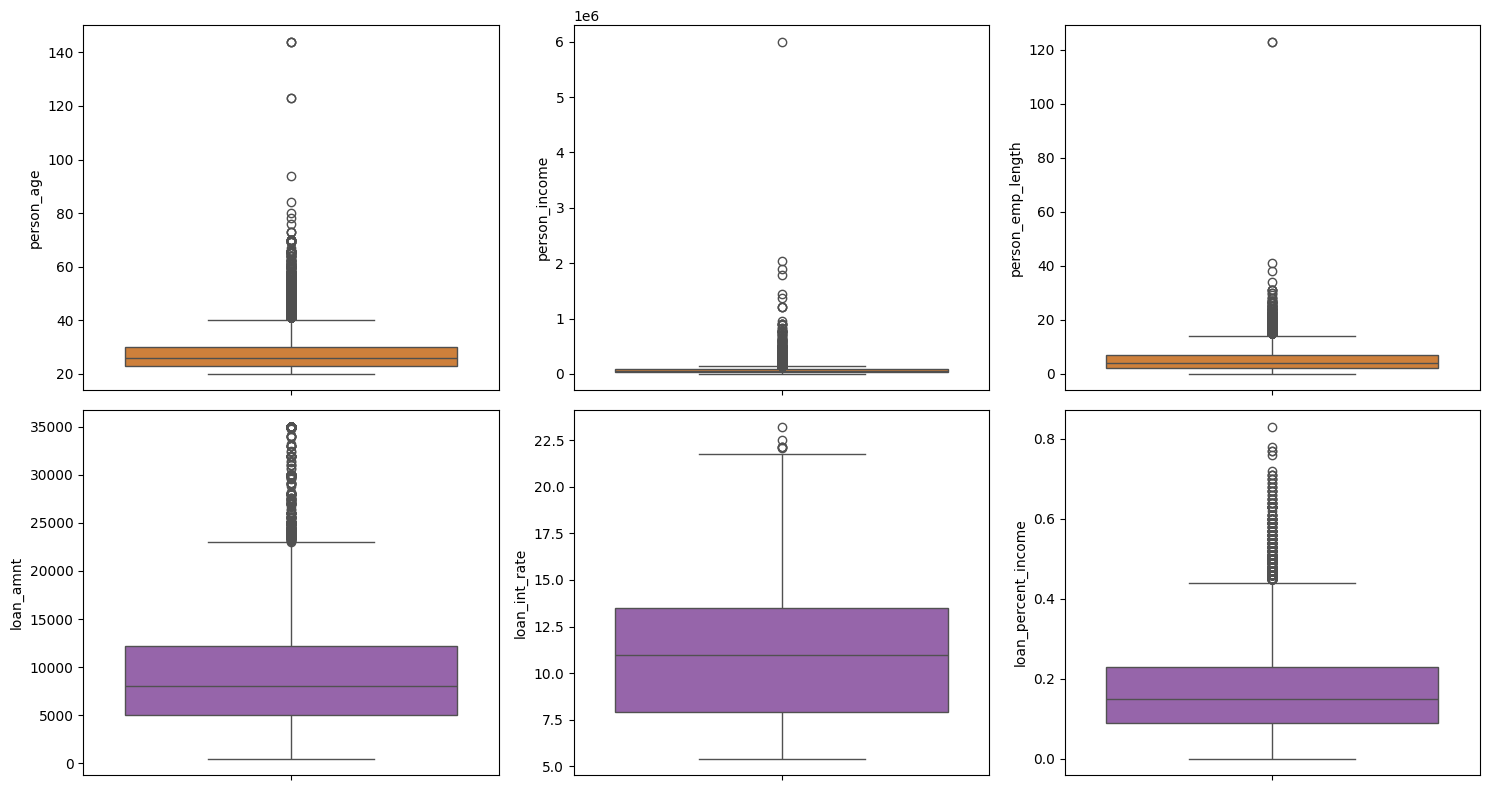

In [ ]:
# Boxplots for outliers
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(y=df['person_age'], ax=axes[0,0], color='#E67E22')
sns.boxplot(y=df['person_income'], ax=axes[0,1], color='#E67E22')
sns.boxplot(y=df['person_emp_length'], ax=axes[0,2], color='#E67E22')
sns.boxplot(y=df['loan_amnt'], ax=axes[1,0], color='#9B59B6')
sns.boxplot(y=df['loan_int_rate'], ax=axes[1,1], color='#9B59B6')
sns.boxplot(y=df['loan_percent_income'], ax=axes[1,2], color='#9B59B6')

plt.tight_layout()
plt.show()

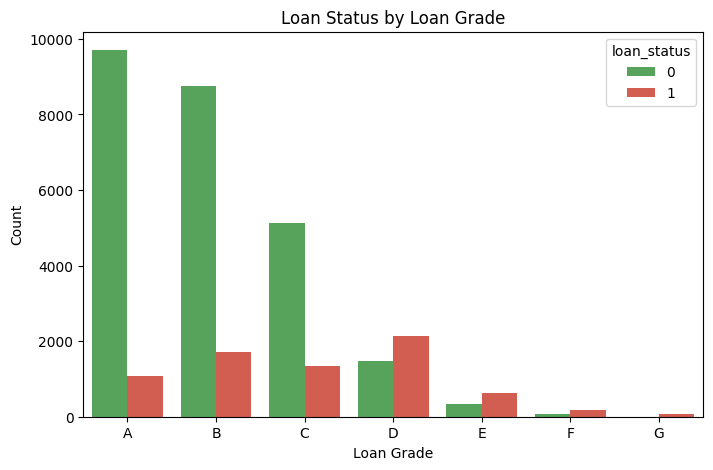

In [ ]:
# Default rate by loan grade
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='loan_grade', hue='loan_status', order=['A','B','C','D','E','F','G'], palette=['#4CAF50','#E74C3C'])
plt.title('Loan Status by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()


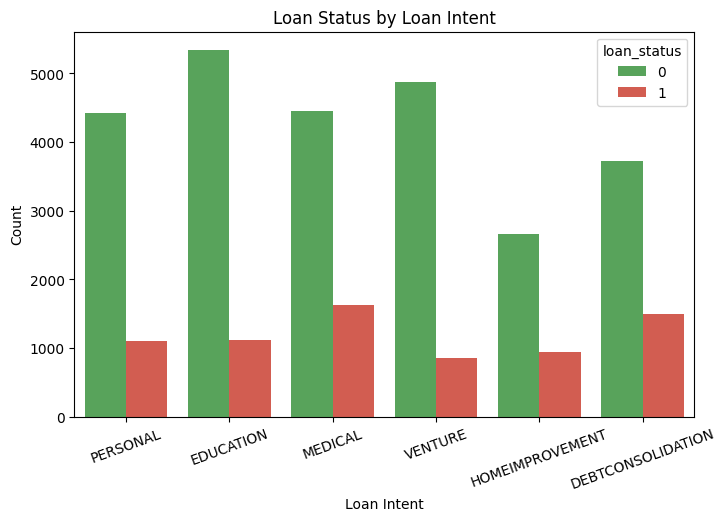

In [ ]:
# Default rate by loan intent
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='loan_intent', hue='loan_status', palette=['#4CAF50','#E74C3C'])
plt.title('Loan Status by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()


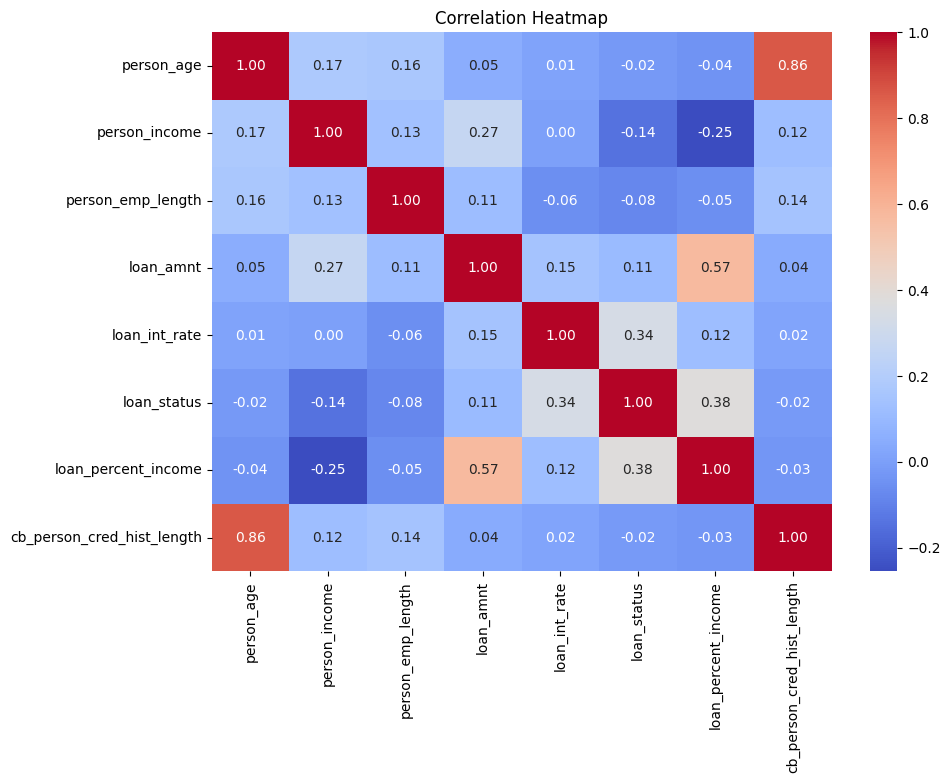

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,7))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print(df.columns)

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


In [ ]:
# 10. Handle Missing Values
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print(df.isnull().sum())

# 11. Remove Duplicates
df = df.drop_duplicates()

print(df.duplicated().sum())
print(df.shape)

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
0
(32416, 12)


In [ ]:
# 12. Separate Features and Target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 13. Identify Numerical and Categorical Columns
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

print(X.shape)
print(y.shape)


(32416, 11)
(32416,)


In [ ]:
# 14. Handle Outliers
print("Age > 100:", (X['person_age'] > 100).sum())
print("Employment length > age:", (X['person_emp_length'] > X['person_age']).sum())

X = X[X['person_age'] <= 100]
X = X[X['person_emp_length'] <= X['person_age']]
y = y[X.index]

print(X.shape)
print(y.shape)

Age > 100: 5
Employment length > age: 2
(32409, 11)
(32409,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Log transform on income (تقليل الانحراف)
X['person_income'] = np.log1p(X['person_income'])

# Label Encoding لـ loan_grade
le = LabelEncoder()
X['loan_grade'] = le.fit_transform(X['loan_grade'])

# One-Hot Encoding للباقي
X = pd.get_dummies(X, columns=['person_home_ownership', 'loan_intent', 'cb_person_default_on_file'], drop_first=True)

print(X.shape)
print(X.columns)

(32409, 17)
Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

print("New X shape:", X_selected.shape)

Selected Features:
Index(['person_income', 'person_emp_length', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='object')
New X shape: (32409, 10)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(25927, 17)
(6482, 17)
loan_status
0    0.781309
1    0.218691
Name: proportion, dtype: float64
loan_status
0    0.78124
1    0.21876
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(25927, 17)
(6482, 17)


In [ ]:
print("Final shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Final shapes:
X_train_scaled: (25927, 17)
X_test_scaled: (6482, 17)
y_train: (25927,)
y_test: (6482,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9128355445850046
Precision: 0.827321565617805
Recall: 0.7602256699576869
F1 Score: 0.7923557515619257
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      5064
           1       0.83      0.76      0.79      1418

    accuracy                           0.91      6482
   macro avg       0.88      0.86      0.87      6482
weighted avg       0.91      0.91      0.91      6482



In [ ]:
from xgboost import XGBClassifier

# حساب نسبة الموازنة يدويًا لـ XGBoost
scale = (y_train == 0).sum() / (y_train == 1).sum()

# Train
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9183893859919778
Precision: 0.8114926419060967
Recall: 0.8166431593794076
F1 Score: 0.8140597539543059
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5064
           1       0.81      0.82      0.81      1418

    accuracy                           0.92      6482
   macro avg       0.88      0.88      0.88      6482
weighted avg       0.92      0.92      0.92      6482



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss'),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best F1 Score (CV):", xgb_grid.best_score_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best F1 Score (CV): 0.8222539346754892


In [ ]:
# أفضل موديل XGBoost بعد الضبط
best_xgb = xgb_grid.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall:", recall_score(y_test, y_pred_best_xgb))
print("F1 Score:", f1_score(y_test, y_pred_best_xgb))
print(classification_report(y_test, y_pred_best_xgb))

Accuracy: 0.9304227090404196
Precision: 0.8745158791634392
Recall: 0.7961918194640338
F1 Score: 0.8335179032853451
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      5064
           1       0.87      0.80      0.83      1418

    accuracy                           0.93      6482
   macro avg       0.91      0.88      0.89      6482
weighted avg       0.93      0.93      0.93      6482



In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best F1 Score (CV):", rf_grid.best_score_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score (CV): 0.8181302662117536


In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Accuracy: 0.9347423634680654
Precision: 0.9627906976744186
Recall: 0.729901269393512
F1 Score: 0.8303249097472925
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5064
           1       0.96      0.73      0.83      1418

    accuracy                           0.93      6482
   macro avg       0.95      0.86      0.89      6482
weighted avg       0.94      0.93      0.93      6482



In [ ]:
final_model = best_xgb

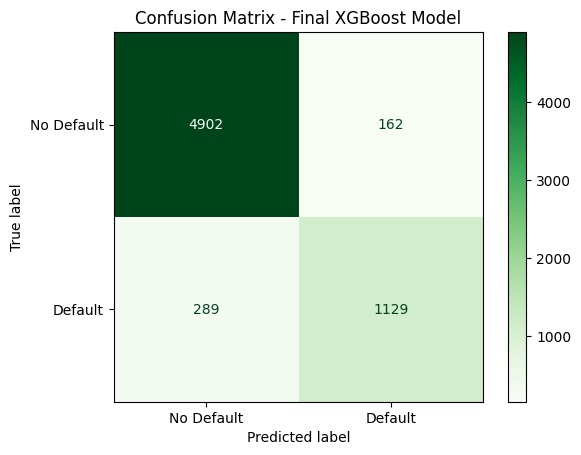

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_best_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Default', 'Default']
)

disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Final XGBoost Model')  # ده بيستخدم matplotlib
plt.show()

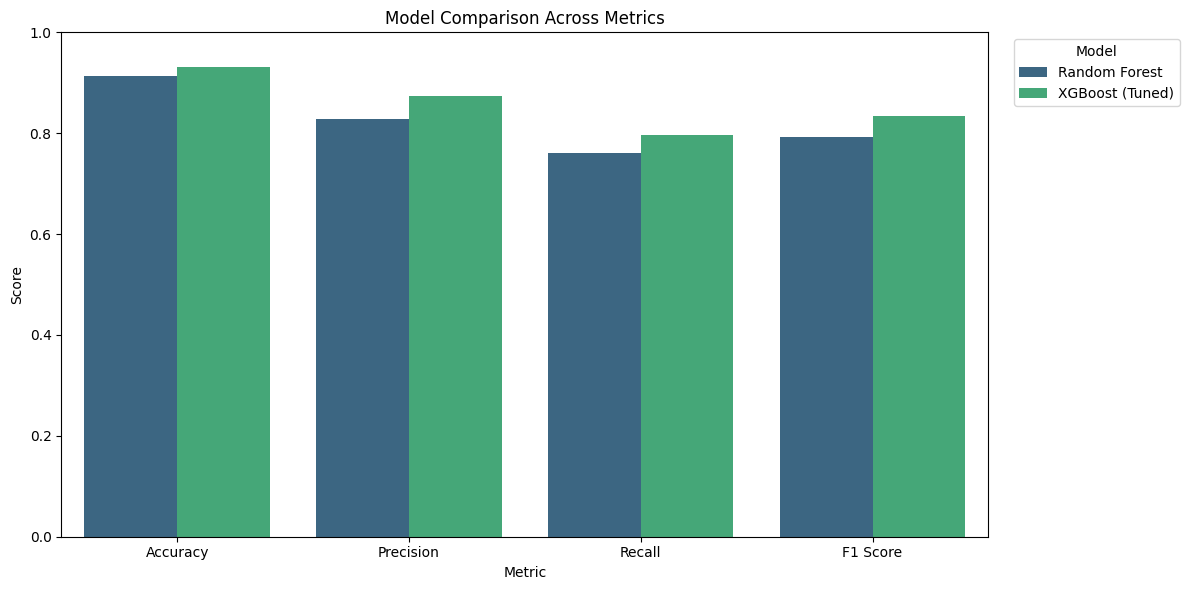

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (Tuned)'],
    'Accuracy': [0.9128, 0.9304],
    'Precision': [0.8273, 0.8746],
    'Recall': [0.7602, 0.7962],
    'F1 Score': [0.7924, 0.8335]
})

results_melted = results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='viridis'
)

plt.title('Model Comparison Across Metrics')
plt.ylim(0, 1)
plt.legend(
    title='Model',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2645/1451987915.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


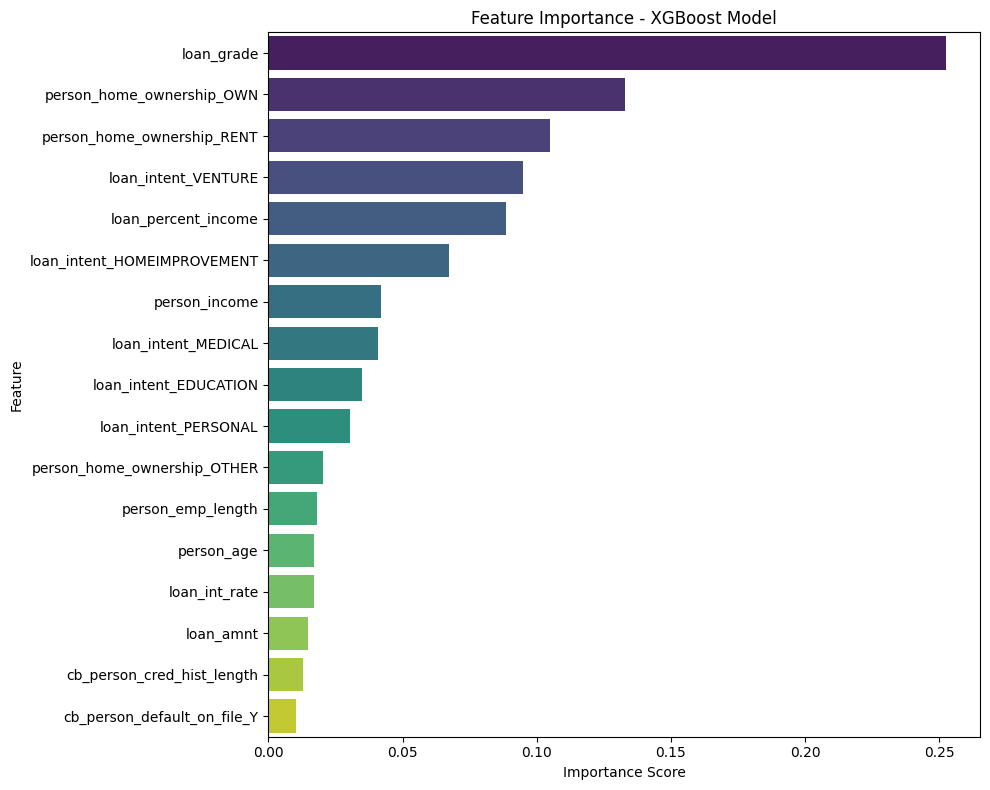

                        Feature  Importance
3                    loan_grade    0.252565
9     person_home_ownership_OWN    0.133050
10   person_home_ownership_RENT    0.105088
15          loan_intent_VENTURE    0.094904
6           loan_percent_income    0.088399
12  loan_intent_HOMEIMPROVEMENT    0.067323
1                 person_income    0.041910
13          loan_intent_MEDICAL    0.040969
11        loan_intent_EDUCATION    0.035000
14         loan_intent_PERSONAL    0.030261
8   person_home_ownership_OTHER    0.020328
2             person_emp_length    0.018123
0                    person_age    0.017087
5                 loan_int_rate    0.016815
4                     loan_amnt    0.014881
7    cb_person_cred_hist_length    0.012978
16  cb_person_default_on_file_Y    0.010320


In [ ]:
importances = best_xgb.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_df)

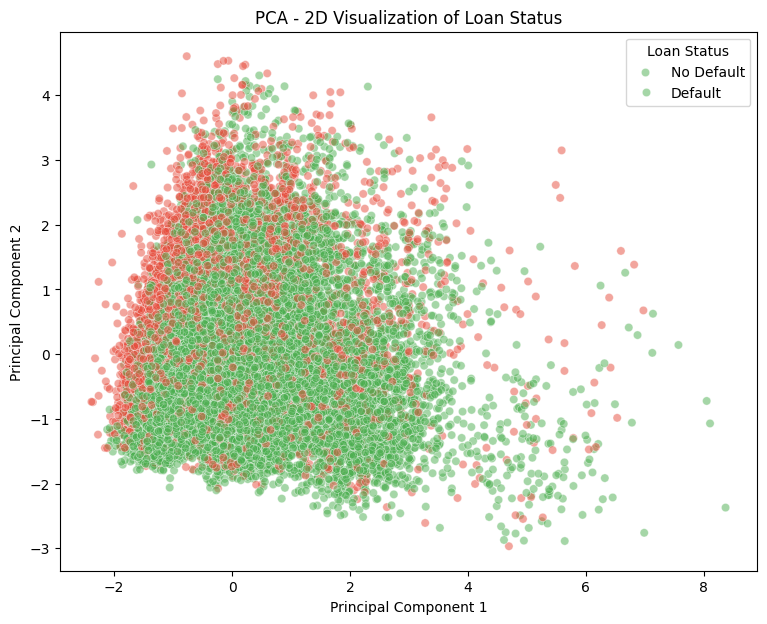

Explained Variance Ratio: [0.23812982 0.19064564]


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(9,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette=['#4CAF50', '#E74C3C'], alpha=0.5)
plt.title('PCA - 2D Visualization of Loan Status')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Loan Status', labels=['No Default', 'Default'])
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

In [ ]:
from sklearn.cluster import KMeans

# اختيار أعمدة مالية بس (من غير الهدف) لعمل التقسيم عليها
cluster_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_percent_income', 'loan_int_rate']
X_cluster = X_train[cluster_cols]

# Scaling خاص بيهم بس
from sklearn.preprocessing import StandardScaler
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# K-Means بـ 4 مجموعات
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# إضافة نتيجة الـ cluster لجدول مؤقت مع الهدف الحقيقي (y_train) عشان نحلل بس، مش للتدريب
segment_df = X_cluster.copy()
segment_df['Cluster'] = clusters
segment_df['loan_status'] = y_train.values

# نسبة التعثر الفعلية في كل مجموعة
default_rate_by_cluster = segment_df.groupby('Cluster')['loan_status'].mean().sort_values(ascending=False)
print(default_rate_by_cluster)

Cluster
2    0.362543
1    0.336895
3    0.158468
0    0.070005
Name: loan_status, dtype: float64


In [ ]:
# متوسط كل عمود في كل Cluster
cluster_profile = segment_df.groupby('Cluster')[cluster_cols].mean()
print(cluster_profile)

         person_age  person_income     loan_amnt  loan_percent_income  \
Cluster                                                                 
0         25.858027      11.153451   6980.608738             0.098843   
1         27.074218      11.205446  19367.009909             0.274820   
2         25.576527      10.377335   6858.491938             0.208628   
3         40.191812      11.043759   8504.052493             0.137233   

         loan_int_rate  
Cluster                 
0             9.561474  
1            12.296940  
2            12.156393  
3            10.989346  


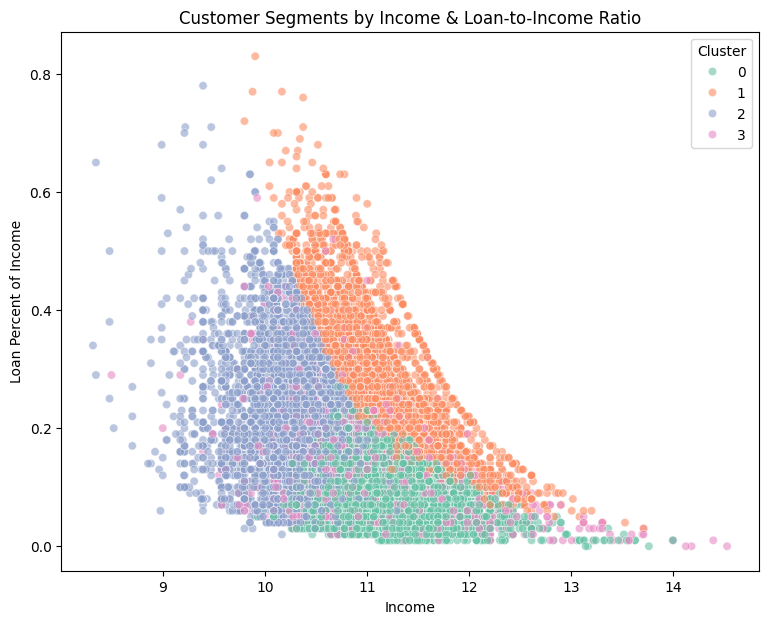

In [ ]:
plt.figure(figsize=(9,7))
sns.scatterplot(
    x=segment_df['person_income'],
    y=segment_df['loan_percent_income'],
    hue=segment_df['Cluster'],
    palette='Set2',
    alpha=0.6
)
plt.title('Customer Segments by Income & Loan-to-Income Ratio')
plt.xlabel('Income')
plt.ylabel('Loan Percent of Income')
plt.legend(title='Cluster')
plt.show()